## Figures for ICOS Science conference presentation 09-2024

In [1]:
# import 

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import pyplot
import os
import matplotlib.ticker as ticker
import numpy as np
import xarray as xr
import sys
import datetime as dt
import string
from cycler import cycler
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime as dt
import itertools
import matplotlib as mpl
import mplotutils as mpu
import matplotlib.dates as mdates
import matplotlib.lines as mlines

## Add parent directory to syspath
parent_dir = os.path.abspath(os.path.join(os.path.dirname('.'), '..'))
if not parent_dir in sys.path:
    sys.path.append(parent_dir)

from utils.utilities import find_best_grid_point, get_station_coords,form_xdate, get_anomalies, adjust_lightness
from utils import process_data
from utils import run_curve_fit
import tol_colors # color schemes from https://personal.sron.nl/~pault/
from utils.ccg_filter import ccg_filter as ccgfilt
from utils.ccg_filter import ccg_dates


#activate interactive figures
%matplotlib widget
#activate autoreload
%load_ext autoreload



### Figure properties

In [2]:
############# Fonts and colors ################
## Colors
 # high contrast color scheme, colorblind safe, grey-scale save, from  https://personal.sron.nl/~pault/
col_contr = tol_colors.tol_cset('high-contrast') #blue, yellow, red, black
col_bright = tol_colors.tol_cset('bright')
col_vibrant = tol_colors.tol_cset('vibrant') # original order: orange blue cyan magenta red teal grey
col_vibrant = [col_vibrant[i] for i in [1,0,5,3,2,4,6]] # use blue first

# IPCC categorical colors "spectrum"
# (from https://github.com/IPCC-WG1/colormaps/tree/master/categorical_colors_rgb_0-255)
# col_cat = []
# [127, 68, 170]
# 48 79 191
# 54 156 232
# 36 147 126
# 236 209 81
# 237 128 55
# 204 64 74

## colormap
cmap = tol_colors.tol_cmap('BuRd_discrete')

alphabets = string.ascii_lowercase

## Figure style:
# fontsize
fs=16
fs_cm = fs*0.0352778

# Figure sizes:
goldenratio = 1.6118
asp16_9 = 16/9
asp4_3 = 4/3
asp3_2 = 3/2

# for papers
figW=8.3
figH = figW / goldenratio 

figW2 = 12
figH2 = figW2 / goldenratio 

# # textwidth in acp paper: 17.7cm
figW3 = 17.7
figH3 = figW3 / goldenratio 


# # For presentation 
#large
figW4 = 15
figH4 = figW4 / asp16_9 
#medium
figW5 = 10
figH5 = figW5 / asp16_9 
#small
figW6 = 5
figH6 = figW6 / asp16_9 

###################################################

def cm2inch(cm_values): #cm2inch(*tupl):
    ''' function to transform cm in inches (inches needed for figures)'''
    inch = 2.54
    return tuple(cm / inch for cm in cm_values)

In [3]:

## -------------------------TO ADAPT------------------------------##
# where to save figures:
dir_save = '../output/presentation202409/' 
save_fig = True

# remove outliers or not
remove_outliers = False #remove outliers based ont uncertainty and statistics
remove_fire_events = True # remove spcific fire events (defined below)


# figure type
fig_format = 'png'
fig_dpi = 400

## Define analyses period
t1 = "2020-01-01"
t2 = "2023-12-31"


# define color of all ink (axes, labels, titles...). 
# Usually black, but could also be grey.
axes_col = 'black' #'dimgrey'
tit_col = 'black'#'black' # label and title colors
my_cols = col_contr #col_vibrant #col_contr
lgd_col = True # color the legend entries
transp=False #save figure transparent or not
lgd_col = True # define if legend text should be colored or not
sig_transp = 0.1 #transparency of sigma shading
marker_transp=0.5 # transparancy of markers when showing data behind smoothed lines


ax_lw = .8 #linewidth of the axes (and ticks and zero line)
pl_lw = 1.2 #linewidth of plotted lines
lw_thick = 2 #+ 0.2 # thicker lines 
lw_thin=0.4 # thinner lines
## -------------------------END ADAPT------------------------------##



In [4]:
############# RC parameters update ###############

#fm._rebuild() # to use local conda environment fonts
#plt.style.use('fivethirtyeight') #this is without ticks!!
mpl.rcParams.update({
    #fontsizes
    'font.size': fs,
    'axes.titlesize':fs,  # fontsize of the axes title
    'figure.titlesize':fs, 
    'axes.labelsize': 'small', #fontsize of the axes labels
    'xtick.labelsize':'small', #'small' is calculated relative to the general fontsize
    'ytick.labelsize':'small', 
    'legend.fontsize':'x-small', #'x-small',
    
    # # copernicus acp font: Nimbus Roman No9 L
    # #'font.family':'monospace',
    # 'font.family': 'serif',
    # 'font.serif': 'Nimbus Roman No9 L',
    # 'font.weight': 'regular',#'normal',
    'mathtext.fontset': 'cm', #'cm', #to use serif font in equations, but not working??

    # I now prefer using a sans-serif font for figures:
    'font.family': 'sans-serif',
    #'font.sans-serif': 'Segoe UI', #'Lato', # not working yet
    #'font.style': 'italic',
    #'font.weight': 'regular',#'normal',

    
    #linewidth and color
    'lines.linewidth':pl_lw, 
    'figure.facecolor':'white',
    'axes.linewidth':ax_lw, 
    'axes.facecolor':'white', 
    'lines.markersize':3,#5,
    'lines.markeredgewidth':pl_lw,

    # axex, ticks, and label colors:
    'axes.edgecolor': axes_col, 
    #ax.xaxis.label.set_color('red')
    #ax.tick_params(axis='x', colors='red')
    'xtick.color' : axes_col,
    'ytick.color' : axes_col,
    'axes.labelcolor' : axes_col,
    'text.color' : axes_col, # sets all text to axes_col, can be problematic
    'axes.titlecolor' : tit_col, 


    #legend
    'legend.edgecolor':'black',#'None',
    'legend.frameon': False, #need to adapt framealpha
    'legend.framealpha':0.5,
    'patch.linewidth':lw_thin, # legend frame line width
    'legend.handlelength':1.2,
    
    # axes and ticks
    'axes.facecolor':'white', 
    'axes.grid': False,
    'grid.linewidth':ax_lw,
    'xtick.bottom': True,
    'ytick.left': True,
    'axes.unicode_minus':False,
    'xtick.major.width': ax_lw,
    'ytick.major.width': ax_lw,

    'axes.spines.top'    : False, #no line at top and right
    'axes.spines.right'  : False,
    
    #colors
    'axes.prop_cycle'    : cycler('color', my_cols),

    ## For mdpi journal: use hyphen for minus signs: 
    'axes.unicode_minus' : True, #use unicode minus instead of hyphen (should be default)

    ## Latex text
    #'text.usetex': True,
    #'text.latex.preamble': [r"\usepackage{amsmath}",], # for the align enivironment
    })

# #use sans-serif for latex math:
# import pylab as plt
# params = {'text.usetex': False, 'mathtext.fontset': 'stixsans',
#     'mathtext.default': 'regular'} # to avoid italic in math environment
# plt.rcParams.update(params)

## For mdpi journal: use hyphen for minus signs: 
#mpl.rcParams.update({'axes.unicode_minus' : True}) 
###################################################

### Read all GHG data

In [6]:
## Read all data
%autoreload 2
from input.read_wdc_data import AvailableData, create_data_reader

# File path
data_path = "../../data/"

# if New data is added to ./data folder, adapt the dictionary in AvailableData
all_data = list(AvailableData)
print(all_data)

#####---------- TO ADAPT ---------------#####
selected_data = ['CO2', 'CO2_flask', 
                 'CO', 'CO_flask', 
                 'CH4', 'CH4_flask', 
                 'O3'
                 ] # define data to read in. If empty, all data is used 
## 
processing_kwargs = { 
    'FLASK_FLAG_CORR' : True # exclude flagged flask-data
}
#####-----------------------------------#####

datasets = [] # initialize list of all datasets 
# read in data
for sel in (selected_data if selected_data else all_data):
    #define where the data has to be read from
    data_reader =  create_data_reader(data_path=data_path,dataset=sel,**processing_kwargs) #creates an instance of the desired data_reader class
    print(f"Data from {data_reader.__class__.__name__} for {sel}:")

    # call the data-reading function on that instance: 
    data = data_reader.read_data() 
    # call the data-processing
    data = data_reader.process_data(data)

    # prepare merged dataset
    data = data.drop(columns='endtime') # problem when merging datasets (because of NaT?), so better remove endtime
    ds = data.to_xarray()
    ds = ds.assign_coords(dataset=sel)
    ds['species'] = data_reader.species
    ds['unit']  = np.unique(ds.unit.dropna(dim='time'))[0]
    datasets.append(ds)

# save all in one xarray dataset
ds_all = xr.concat(datasets,dim="dataset")
ds_all

['CO2', 'CO2_flask', 'CO', 'CO_flask', 'CO_2002-2006', 'CH4', 'CH4_flask', 'O3', 'aerosols_2015', 'aerosols', 'other_gases_ebas', 'other_gases_wdc', 'meteo']
Data from wdcGHGReader for CO2:
Data from wdcFlaskReader for CO2_flask:
Data from wdcGHGReader for CO:
Data from wdcFlaskReader for CO_flask:
Data from wdcGHGReader for CH4:
Data from wdcFlaskReader for CH4_flask:
Data from ebasReader for O3:


<xarray.Dataset>
Dimensions:             (time: 114106, dataset: 7)
Coordinates:
  * time                (time) datetime64[ns] 2002-05-31T23:00:00 ... 2023-12...
  * dataset             (dataset) <U9 'CO2' 'CO2_flask' ... 'CH4_flask' 'O3'
Data variables: (12/17)
    site_gaw_id         (dataset, time) object nan nan nan nan ... nan nan nan
    value               (dataset, time) float64 nan nan nan ... 32.78 36.53
    value_unc           (dataset, time) float64 nan nan nan ... 2.32 0.7698
    nvalue              (dataset, time) float64 nan nan nan nan ... nan nan nan
    latitude            (dataset, time) float64 nan nan nan nan ... nan nan nan
    longitude           (dataset, time) float64 nan nan nan nan ... nan nan nan
    ...                  ...
    QCflag              (dataset, time) float64 nan nan nan nan ... 0.0 0.0 0.0
    instrument          (dataset, time) float64 nan nan nan nan ... nan nan nan
    measurement_method  (dataset, time) float64 nan nan nan nan ... nan nan nan
    scale               (dataset, time) float64 nan nan nan nan ... nan nan nan
    unit                (dataset) <U3 'ppm' 'ppm' 'ppb' 'ppb' 'ppb' 'ppb' 'ppb'
    species             (dataset) <U3 'CO2' 'CO2' 'CO' 'CO' 'CH4' 'CH4' 'O3'

#### Remove outliers (e.g. CO peak)

In [7]:

fire_dates_Mar2022 = slice('2022-03-13','2022-03-27')
fire_times_Mar2022 = ds_all.sel(time=fire_dates_Mar2022).time.values

fire_dates_Mar2021 = slice('2021-03-20','2021-03-28')
fire_times_Mar2021 = ds_all.sel(time=fire_dates_Mar2021).time.values

if remove_fire_events:    # remove fire events from the dataset. Use a workaround, because xarray adds time dimension to all variables
    ds_withtime = ds_all.drop([ var for var in ds_all.variables if not 'time' in ds_all[var].dims ])
    ds_timeless = ds_all.drop([ var for var in ds_all.variables if     'time' in ds_all[var].dims ])
    ds_withtime = ds_withtime.where(ds_withtime.time.isin(fire_times_Mar2022)==False) #don't use the fire event times 2022
    ds_withtime = ds_withtime.where(ds_withtime.time.isin(fire_times_Mar2021)==False) #don't use the fire event times 2021
    ds_all_rem_out = xr.merge([ds_timeless, ds_withtime])

if remove_outliers:
    # Remove outliers that exceed 10*stdedeviation_mean and 4* the zscore 
    # remove outliers for each species sperarately
    ds_all_rem_out = ds_all.copy(deep=True) #use deepcopy, otherwise it replaces values in ds_all!
    outlier_masks = {}
    for ds in np.unique(ds_all.species):
        print(f"remove outliers for {ds}:")
        ds_all_rem_out.loc[dict(dataset=ds)], mask_removed_outliers= process_data.rem_out(ds_all.sel(dataset=ds), std_fac=10, z_threshold=4)
        outlier_masks[ds] = mask_removed_outliers

    #ds_all = ds_all_rem_out # use the removed outlier data!


C:\Users\leob\AppData\Local\Temp\ipykernel_32\456252165.py:8: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds_withtime = ds_all.drop([ var for var in ds_all.variables if not 'time' in ds_all[var].dims ])
C:\Users\leob\AppData\Local\Temp\ipykernel_32\456252165.py:9: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds_timeless = ds_all.drop([ var for var in ds_all.variables if     'time' in ds_all[var].dims ])


### GHG time series plots

In [56]:
## Helper functions for the figure

import matplotlib.colors as mc
from labellines import labelLine, labelLines
import colorsys 

# adjust the lightness of a color
def adjust_lightness(color, amount=0.5):
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], max(0, min(1, amount * c[1])), c[2])

# function to plot each subplot
# time series plot
def plot_data(ds_temp, ds_temp_fit, label,ax=None, detrend=False, plot_measurements=True, plot_fit=True, **kwargs):
    ''' 
    Plot the data and the fit
    detrend: if True, plot the detrended data
    '''
    if ax is None:
        ax = plt.gca()

    ## get initial figure properties
    initial_color = kwargs['color']
    initial_ls = kwargs['ls']
    initial_zorder = kwargs['zorder']
    
    if plot_measurements:
        kwargs['ls'] = '' #no line for measurements
        pl = ds_temp.plot(
            ax=ax,
            alpha=marker_transp,
            label='',#label[0:4],
            #markeredgewidth=0,
            **kwargs
        )
    else:
        pl = []
    #plot fit
    if plot_fit:
        kwargs['color'] = adjust_lightness(initial_color,amount=1.5) # adapt hue of initial color (lighter)
        kwargs['marker'] = '' #no marker for fit
        kwargs['ls'] = initial_ls
        kwargs['zorder'] = initial_zorder + 1 # plot fit on top of measurements
        pl_fit = ds_temp_fit["smoothed_vals"].plot(ax=ax, label=label, **kwargs)
        if detrend:
            #plot detrended fit
            kwargs['color'] = adjust_lightness(initial_color,amount=0.8)  # adapt hue of initial color (darker)
            kwargs['ls'] = ':' #dotted line for detrended
            ax.plot(
                ds_temp_fit.time,
                ds_temp_fit["seasonal_detrend"] + ds_temp_fit["smoothed_vals"].mean(),
                label="detrended fit",
                **kwargs,
            )  ## Add mean value to detrended to obtain same magnitude
    else:
        pl_fit = []
    return pl, pl_fit

# seasonality plot
def plot_cycle(ds_temp, ds_temp_fit, s, freq="month", ax=None, with_trend = False, plot_smoothed=True, label='', **kwargs):
    '''
    Plot seasonal cycle of the data
    with_trend:  if True, plot the seasonal cycle with trend (non-detrended)
    plot_smootehd:  Plot the smoothed or the original data
    '''
    
    ## get a different hue of the color used
    # Decrease the hue value
    initial_color = kwargs['color']
    
    if ax is None:
        ax = plt.gca()
    ref = (
        ds_temp.mean()
    )  # use mean value from measurements to obtain positive/neg. seasonality (ds_temp-ref) or absolute values (ds_temp_fit +ref)

    if freq=='hour':
        kwargs['color'] = adjust_lightness(initial_color,amount=1.2)  # adapt hue of initial color (lighter)
        
        xvals = (ds_temp-ref).groupby(f"time.{freq}").mean()
        pl = xvals.plot(
            ax=ax, label=f"{label}",**kwargs
        )
        std = (ds_temp-ref).groupby(f"time.{freq}").std() # standarddeviation of the grouped values of the measurements
        #add stdev
        ax.fill_between(xvals[freq],xvals,xvals+std,alpha=.3,label=f'std. dev.',color=kwargs['color'])
        ax.fill_between(xvals[freq],xvals,xvals-std,alpha=.3,label=f'std. dev.',color=kwargs['color'])
    else:
        # normal seasonal cycle
        if with_trend:
            kwargs['ls'] = ':' #dotted line for not detrended
            kwargs['color'] = adjust_lightness(initial_color,amount=0.8) # adapt hue of initial color (darker)
            #plot also the normal seasonal cycle (with trend) in addition
            (ds_temp-ref).groupby(f"time.{freq}").mean().plot(ax=ax, label=f"{label} not detrended",**kwargs)
        # detrended seasonal cycle
        kwargs['color'] = adjust_lightness(initial_color,amount=1.2)  # adapt hue of initial color (lighter)

        if plot_smoothed:
            xvals = ds_temp_fit["seasonal_detrend"].groupby(f"time.{freq}").mean()
            std = ds_temp_fit["seasonal_detrend"].groupby(f"time.{freq}").std() # standarddeviation of the grouped values of the measurements
        else:
            xvals = (ds_temp-ref).groupby(f"time.{freq}").mean()
            std = (ds_temp-ref).groupby(f"time.{freq}").std() 
            

        pl = xvals.plot(
            ax=ax, label=f"{label}", **kwargs
        ) #label=f"{label} detrended"

        #add stdev
        ax.fill_between(xvals[freq],xvals,xvals+std,alpha=.3,label=f'std. dev.',color=kwargs['color'])
        ax.fill_between(xvals[freq],xvals,xvals-std,alpha=.3,label=f'std. dev.',color=kwargs['color'])
    return pl


In [9]:
## Define the data periods I want to compare/plot ##! TO ADAPT!

t0 = ds_all.isel(time=0)
t1 = ds_all.isel(time=-1)
print(f"Total time period with data:: {t0.time.values} to {t1.time.values}")

compare_periods = {
    'A': (t0.time.values, dt.datetime(2006,12,31)), #old and flask data
    'B': (dt.datetime(2008,1,1), dt.datetime(2011,12,31)), #only flask data
    #'C0': (dt.datetime(2020,1,1), t1.time.values), # only new data
    'C': (dt.datetime(2014,1,1), t1.time.values) # only ozone data
}


Total time period with data:: 2002-05-31T23:00:00.000000000 to 2023-12-31T23:00:00.000000000


In [28]:
# Define fit paramaters for the curve fitting
# Default values
fit_params_defaults = {'shortterm': 80, #Short term cutoff value in days for smoothing of data
                'longterm': 667, # smoothing in days. Default: 667
                'numpolyterms': 3, # use only 2 for less than 3 years of data, otherwise use 3 (=quadratic fit)
                'sampleinterval': 1 / 24,  # 1h
                'numharmonics': 4}

fit_properties = {}
for dataset in ds_all.dataset:
    dataset_name = dataset.values.item()  # Convert numpy array to a hashable type
    fit_properties[dataset_name] = fit_params_defaults.copy()
    
# Update fit_properties with non-default values if necessary:
# Remove sampleinterval for flask data:
for dataset in fit_properties:
    if '_flask' in dataset:
        fit_properties[dataset]['sampleinterval'] = 0 #if 0, determine from xp (time)

#fit_properties['CO']['numpolyterms'] = 3


Period A: 2002-05-31T23:00:00.000000000 to 2006-12-31 00:00:00
Period B: 2008-01-01 00:00:00 to 2011-12-31 00:00:00
Period C: 2014-01-01 00:00:00 to 2023-12-31T23:00:00.000000000


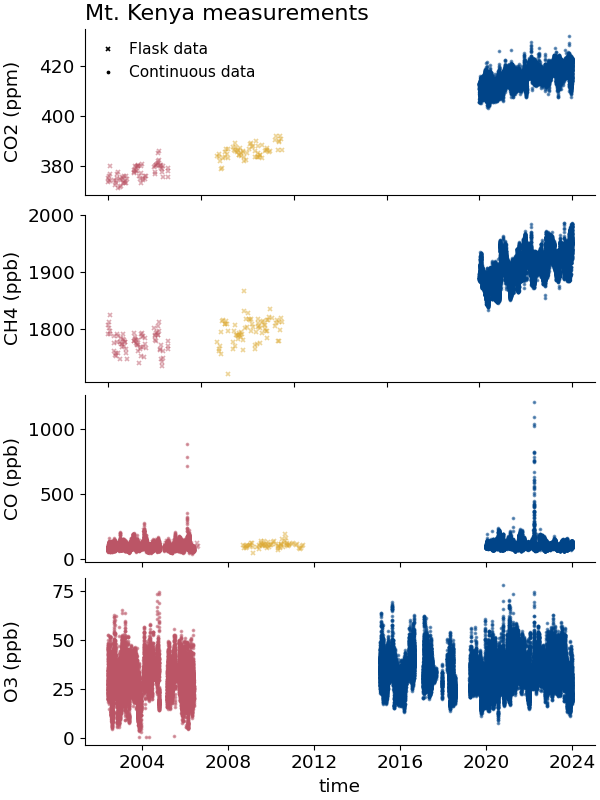

In [15]:
### Plot with all 3 periods (without seasonal cycles)
with_curve_fit = False # plot the curve fit or not

# species to plot
my_species = [ 'CO2', 'CH4', 'CO', 'O3']
#my_species = [ 'CO']

# dataset to use:
ds_data = ds_all #normal measurement data
#ds_data = ds_all_rem_out  # use data with removed outliers!!

# only select data where the species is in my_species:
ds_data = ds_data.where(ds_data.species.isin(my_species), drop=True)

##---- Plotting definitions ----##
with_trend = False #if true, plot detrended data, otherwise detrend 

default_colors = ['C2', 'C1', 'C0', 'C3'] if len(compare_periods) >2 else ['C0', 'C1', 'C2', 'C3'] # make third period blue
#default_colors = ['C0', 'C0', 'C0', 'C3'] if len(compare_periods) >2 else ['C0', 'C1', 'C2', 'C3'] # make third period blue
color_iterator = itertools.cycle(default_colors)


##--- Start figure  ---##
# Make a mosaic grid, where each subplot is called either the species (e.g. CO2) or the species seasonal cycle (ew.g. CO2_seas)

mosaic_grids =  [[m]  for m in my_species] # put [] around to start new row
gs_kw = dict(width_ratios=[1]) #column and width ratios
subfig_height = 2.5 if len(my_species) == 1 else 2
fig, axd = plt.subplot_mosaic(mosaic_grids,
                              gridspec_kw=gs_kw, figsize=(6,8),
                              layout="constrained")
                              
for period, (start_date, end_date) in compare_periods.items():
    print(f"Period {period}: {start_date} to {end_date}")
    # Filter the data for the current period
    period_data = ds_data.sel(time=slice(start_date, end_date))

    # Define figure properties for this period
    fig_properties = {
        'color': next(color_iterator),
        'marker': '.',
        'ls':'-'
    }

    # Write Period A, B and C just below the time axis in the color of the different periods
    # write it on top of the first axis
    ax_sel = axd[my_species[0]] # first subplot
    #ax_sel.text(start_date, 400, f'Period {period}',color=fig_properties['color'], ha='left') #, transform=ax_sel.transAxes

    ## Loop through all datasets and plot the data
    for i,dataset in enumerate(period_data.dataset):
        # Get the data for the current dataset and period
        data = period_data.sel(dataset=dataset)["value"]
        species = period_data.sel(dataset=dataset).species.values
        #print(f"Dataset: {dataset.item()}, Species: {species}")

        if data.size > 0 and np.all(np.isnan(data))==False: #if we have data
        
            # Define fit properties for this dataset
            # Perform the curve fitting and obtain the interpolated time axis
            if with_curve_fit:
                filt, df_interp, ds_interp = run_curve_fit.run_ccgfilter(
                    ds=data,
                    dataset_str=dataset.item(),
                    t1=start_date,
                    t2=end_date,
                    **fit_properties[dataset.item()]
                )
              
            # Plot the data and the fit
            # adapt figure properties for flask data
            if dataset.item() == 'CO_flask':
                # CO_flask is the only flask data that we have in parallel with continuous measurements
                # Therefore, we plot it with a different marker and linestyle
                fig_properties['marker'] = 'x'
                #fig_properties['color'] = 'lightgrey'
                fig_properties['zorder'] = 5
                fig_properties['ls'] = '--'
            elif '_flask' in dataset.item():
                # different marker for flask measurements
                fig_properties['marker'] = 'x'
            else:
                # normal properties
                fig_properties['marker'] = '.'
                fig_properties['ls'] = '-'

           
            ## Time series figure
            ax_ts = axd[species.item()]

            legend_entry = f"curve fit ({fit_properties[dataset.item()]['shortterm']} days)"
            plot_data(data,                       
                      ds_interp,
                      legend_entry, 
                      ax_ts,
                      with_trend,
                      plot_fit=with_curve_fit,
                      **fig_properties)

            #---- figure properties ----#

            # axes properties time series
            ax_ts.set_ylabel(f"{species} ({period_data.sel(dataset=dataset).unit.values})")
            #ax_ts.set_xlim(np.array([t1, t2], dtype="datetime64"))
            ax_ts.spines["top"].set_visible(False)
            ax_ts.spines["right"].set_visible(False)
            ax_ts.set_title("")

            if species != my_species[-1]:  # all except lowest axis
                plt.setp(
                    ax_ts.get_xticklabels(), visible=False
                )  # remove xticklabels except for lowest plot
                ax_ts.set_xlabel("")


## --- Final figure properties ---##
handles, labels = ax_ts.get_legend_handles_labels()
# manually adapt legend:
labels[0] = "1h data"
ax0 = list(axd.values())[0] #first subplot (upper left)
if with_trend:
    ax0.legend(handles, labels, loc="lower right")
fig.align_ylabels()

# Add a manual legend showing the shape of the dots to the lower left subplot
marker_flask = mlines.Line2D([], [], color='k', marker='x', linestyle='None', label='Flask data')
marker_other = mlines.Line2D([], [], color='k', marker='.', linestyle='None',label='Continuous data')
ax0.legend(handles=[marker_flask,marker_other], loc='upper left')

# # Add the legend to the upper right subplot (cycles)
# ax_sel = axd[my_species[0] +'_seas']
# handles, labels = ax_sel.get_legend_handles_labels()
# labelLines(ax_sel.get_lines(), zorder=2.5)
# #ax_sel.legend(handles, labels, loc='upper left')

# place title on first axis
ax0.set_title("Mt. Kenya measurements", loc="left")

str_trend = '_detrended' if with_trend else ''


# if not all species are plotted: adapt name
if len(my_species) <4:
    str_spec = '_' + ''.join(my_species)
else:
    str_spec = ''
if save_fig:
    plt.savefig(
        f"{dir_save}timeseries_and_fit{str_trend}_{len(compare_periods)}periods{str_spec}.png", dpi=fig_dpi
    )

Period A: 2020-01-01 00:00:00 to 2023-12-31T23:00:00.000000000
Run filter for CO2
Run filter for CO
Run filter for CH4
Run filter for O3


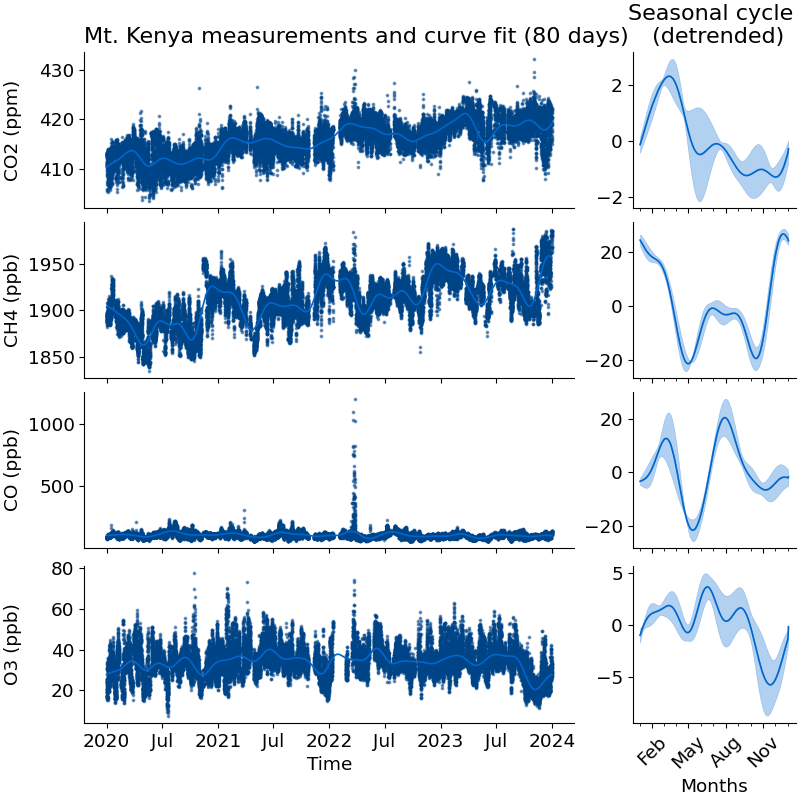

In [30]:
## All GHG after 2020 with seasonal cycles

%autoreload 2


#only newest data
compare_periods = {
    'A': (dt.datetime(2020,1,1), t1.time.values), # only new data
}

# species to plot
my_species = [ 'CO2', 'CH4', 'CO', 'O3']
#my_species = [ 'CO']


##---- Plotting definitions ----##
save_fig = True
# plot seasonal or daily cycles
plot_seas = True #if false, plot daily cycle instead of seasonal
seas_freq = 'dayofyear' # 'month' or 'dayofyear'
with_trend = False #if true, plot detrended data, otherwise detrend seasonal cycle but dont plot it as extra line in the time series plot
#with_outliers = True # use data where outliers are removed or not

default_colors = ['C2', 'C1', 'C0', 'C3'] if len(compare_periods) >2 else ['C0', 'C1', 'C2', 'C3'] # make third period blue
#default_colors = ['C0', 'C0', 'C0', 'C3'] if len(compare_periods) >2 else ['C0', 'C1', 'C2', 'C3'] # make third period blue
color_iterator = itertools.cycle(default_colors)

for with_outliers in [False, True]:
    # dataset to use:
    if with_outliers:
        ds_data = ds_all #normal measurement data (outliers not removed)
    else:
        ds_data = ds_all_rem_out  # use data with removed outliers!!
    # only select data where the species is in my_species:
    ds_data = ds_data.where(ds_data.species.isin(my_species), drop=True)


    ##--- Start figure  ---##
    # Make a mosaic grid, where each subplot is called either the species (e.g. CO2) or the species seasonal cycle (ew.g. CO2_seas)

    mosaic_grids =  [[m, m+'_seas']  for m in my_species] # put [] around to start new row
    gs_kw = dict(width_ratios=[3, 1]) #column and width ratios
    subfig_height = 2.5 if len(my_species) == 1 else 2
    fig, axd = plt.subplot_mosaic(mosaic_grids,
                                gridspec_kw=gs_kw, figsize=(8,8),
                                layout="constrained")
                                
    for period, (start_date, end_date) in compare_periods.items():
        print(f"Period {period}: {start_date} to {end_date}")
        # Filter the data for the current period
        period_data = ds_data.sel(time=slice(start_date, end_date))

        # Define figure properties for this period
        fig_properties = {
            'color': next(color_iterator),
            'marker': '.',
            'ls':'-'
        }

        
        # # Write Period A, B and C just below the time axis in the color of the different periods
        # # write it on top of the first axis
        # ax_sel = axd[my_species[0]] # first subplot
        # ax_sel.text(start_date, 400, f'Period {period}',color=fig_properties['color'], ha='left') #, transform=ax_sel.transAxes

        ## Loop through all datasets and plot the data
        for i,dataset in enumerate(period_data.dataset):
            # Get the data for the current dataset and period
            data = period_data.sel(dataset=dataset)["value"]
            species = period_data.sel(dataset=dataset).species.values
            #print(f"Dataset: {dataset.item()}, Species: {species}")

            if data.size > 0 and np.all(np.isnan(data))==False: #if we have data
            
                # Define fit properties for this dataset
                # Perform the curve fitting and obtain the interpolated time axis
                filt, df_interp, ds_interp = run_curve_fit.run_ccgfilter(
                    ds=data,
                    dataset_str=dataset.item(),
                    t1=start_date,
                    t2=end_date,
                    **fit_properties[dataset.item()]
                )
                
                # Plot the data and the fit
                # adapt figure properties for flask data
                if dataset.item() == 'CO_flask':
                    # CO_flask is the only flask data that we have in parallel with continuous measurements
                    # Therefore, we plot it with a different marker and linestyle
                    fig_properties['marker'] = 'x'
                    #fig_properties['color'] = 'lightgrey'
                    fig_properties['zorder'] = 5
                    fig_properties['ls'] = '--'
                elif '_flask' in dataset.item():
                    # different marker for flask measurements
                    fig_properties['marker'] = 'x'
                else:
                    # normal properties
                    fig_properties['marker'] = '.'
                    fig_properties['ls'] = '-'

            
                ## Time series figure
                ax_ts = axd[species.item()]
                ## Seasonal cycle figure
                ax_seas = axd[species.item()+'_seas']


                legend_entry = f"curve fit ({fit_properties[dataset.item()]['shortterm']} days)"
                plot_data(data,                       
                        ds_interp,
                        legend_entry, 
                        ax_ts,
                        with_trend
                        ,**fig_properties)

                #plot seasonal cycle
                freq = seas_freq if plot_seas else 'hour' #for seasonal cycle, use 'dayofyear' (smoother line) or 'month', for daily cycle (if plot_seas=False) use 'hour'
                # no markers for seasonal cycle
                fig_properties['marker'] = '' #no marker for seasonal cycle
                pl_seas = plot_cycle(
                    data,
                    ds_interp,
                    species,
                    freq= freq,
                    ax=ax_seas,
                    with_trend=with_trend,
                    label = period,
                    **fig_properties
                )


                #---- figure properties ----#

                # axes properties time series
                ax_ts.set_ylabel(f"{species} ({period_data.sel(dataset=dataset).unit.values})")
                #ax_ts.set_xlim(np.array([t1, t2], dtype="datetime64"))
                ax_ts.spines["top"].set_visible(False)
                ax_ts.spines["right"].set_visible(False)
                ax_ts.set_title("")

                if species != my_species[-1]:  # all except lowest axis
                    plt.setp(
                        ax_ts.get_xticklabels(), visible=False
                    )  # remove xticklabels except for lowest plot
                    ax_ts.set_xlabel("")
                else: #lowest axis
                    ax_ts.set_xlabel("Time")

                # axes properties seasonal cycle
                # ax_seas.set_yticklabels('') #this removes ylabels for both axes! Therefore better use:
                #ax_seas.tick_params(labelleft=False) #I need the labels if I use other units for the seasoal cycle!!
                ax_seas.set_title("")
                ax_seas.set_ylabel("")
                ax_seas.spines["top"].set_visible(False)
                ax_seas.spines["right"].set_visible(False)
                if plot_seas:
                    if freq== 'month':
                        months = range(1, 13, 3)
                        ax_seas.set_xticks(
                            months,
                            [dt.datetime.strptime(str(month), "%m").strftime("%b") for month in months],
                        )
                        #rotate the xlabels
                        plt.setp(ax_seas.xaxis.get_majorticklabels(), rotation=45)
                    elif freq == 'dayofyear':
                        ax_seas.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
                        ax_seas.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))
                        ax_seas.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
                        #rotate the xlabels
                        plt.setp(ax_seas.xaxis.get_majorticklabels(), rotation=45)

                #ax_seas.grid(color='lightgrey',zorder=0,axis='x')
                ax_seas.set_axisbelow(False)

                # different for lowest plot
                if species != my_species[-1]:  # all except lowest axis
                    plt.setp(
                        ax_seas.get_xticklabels(), visible=False
                    )  # remove xticklabels except for lowest plot
                    ax_seas.set_xlabel("")
                else: #lowest axis
                    ax_seas.set_xlabel("Months" if plot_seas else "Hours")

    ## --- Final figure properties ---##
    handles, labels = ax_ts.get_legend_handles_labels()
    # manually adapt legend:
    labels[0] = "1h data"
    ax0 = list(axd.values())[0] #first subplot (upper left)
    if with_trend:
        ax0.legend(handles, labels, loc="lower right")
    fig.align_ylabels()


    # place title on first axis
    ax0.set_title(f"Mt. Kenya measurements and curve fit ({fit_properties[dataset.item()]['shortterm']} days)", loc="left")
    ax1 = list(axd.values())[1] #second subplot (upper right)
    if plot_seas:
        tit_right = "Seasonal cycle \n (detrended)"
    else:
        tit_right = 'Diurnal cycle'
    ax1.set_title(tit_right, loc="center")


    str_seas = 'seas' if plot_seas else 'daily'
    str_trend = '_detrended' if with_trend else ''
    str_trend = str_trend + f"{fit_properties[dataset.item()]['shortterm']}d" 
    str_freq = '_' + seas_freq if plot_seas else ''

    # if not all species are plotted: adapt name
    if len(my_species) <4:
        str_spec = '_' + ''.join(my_species)
    else:
        str_spec = ''
    if with_outliers:
        str_spec += '_with_outliers'
    if save_fig:
        plt.savefig(
            f"{dir_save}timeseries_and_{str_seas}{str_freq}_fit{str_trend}_from2020_{str_spec}.png", dpi=fig_dpi
    )

#### Same figure but with CAMS data in addition
Note that our observatoins are 1h data, CAMS is 3h (or 6h for CH4)

In [19]:
## Load the selected cams data at Mt. Kenya
cams_best_grid = xr.open_dataset(f"{data_path}/level3/cams/cams_best_grid_merged_MKN.nc") #selection where 2 invgg periods (different resolution) were merged

## Remove cams products that I don't want to plot
cams_best_grid = cams_best_grid.drop_sel(dataset=["co2_egg4","ch4_egg4"])

Period A: 2020-01-01 00:00:00 to 2023-12-31T23:00:00.000000000
Run filter for CO2
Run filter for CO2
Run filter for CH4
Run filter for CH4
Run filter for CO
Run filter for CO
Run filter for O3
Run filter for O3


c:\Users\leob\Documents\Data_analyses\KADI\gawkenya\venv\Lib\site-packages\labellines\core.py:151: UserWarning: Tried to label line Line2D(_child0), but could not find a label for it.
  warnings.warn(
c:\Users\leob\Documents\Data_analyses\KADI\gawkenya\venv\Lib\site-packages\labellines\core.py:151: UserWarning: Tried to label line Line2D(_child3), but could not find a label for it.
  warnings.warn(


Period A: 2020-01-01 00:00:00 to 2023-12-31T23:00:00.000000000
Run filter for CO2
Run filter for CO2
Run filter for CH4
Run filter for CH4
Run filter for CO
Run filter for CO
Run filter for O3
Run filter for O3


c:\Users\leob\Documents\Data_analyses\KADI\gawkenya\venv\Lib\site-packages\labellines\core.py:151: UserWarning: Tried to label line Line2D(_child0), but could not find a label for it.
  warnings.warn(
c:\Users\leob\Documents\Data_analyses\KADI\gawkenya\venv\Lib\site-packages\labellines\core.py:151: UserWarning: Tried to label line Line2D(_child3), but could not find a label for it.
  warnings.warn(


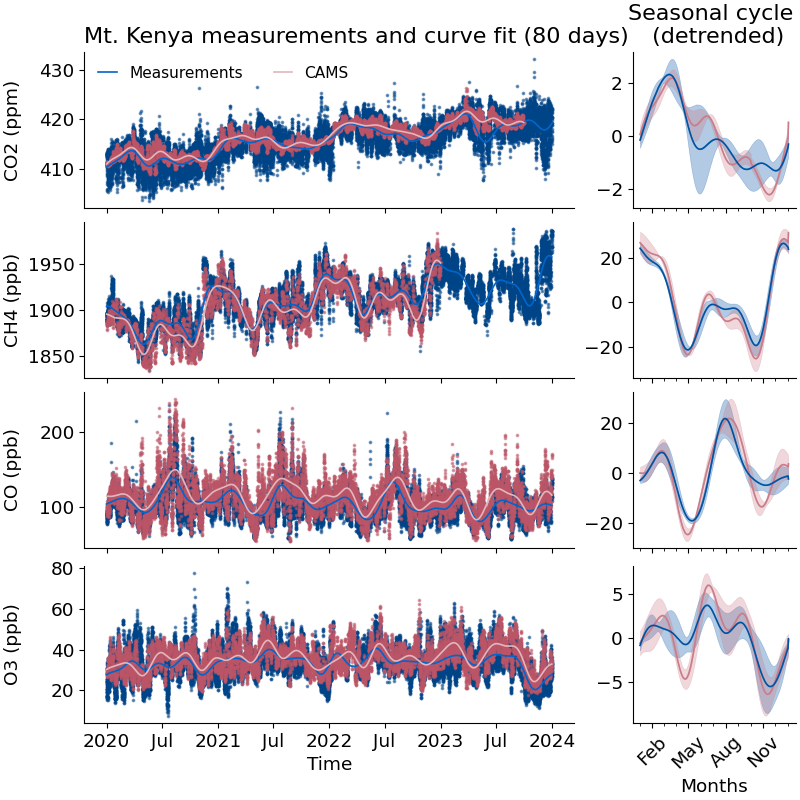

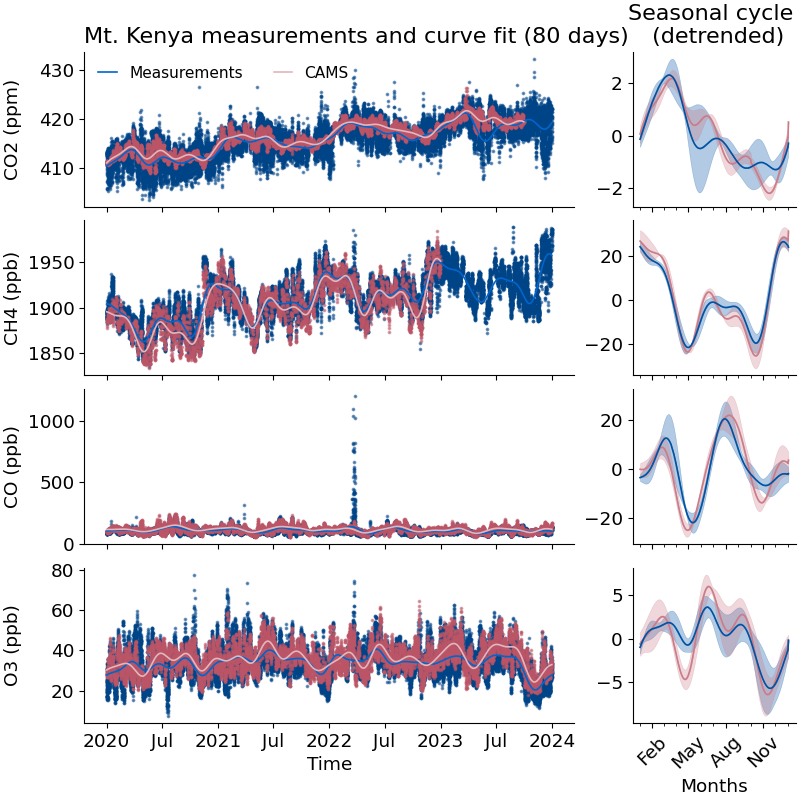

In [57]:
### Figure to compare cams with newest measurement data, including line fits
# it only works with the newest data from 2020 and not with flask data!
# The reason is because we are looping through the species, so the dataset and sepcies name has to be the same (e.g. 'CO2', the dataset 'CO2_flask' would not work)

#only newest data
compare_periods = {
    'A': (dt.datetime(2020,1,1), t1.time.values), # only new data
}

# species to plot
my_species = [ 'CO2', 'CH4', 'CO', 'O3']


##---- Plotting definitions ----##
save_fig = True
# plot seasonal or daily cycles
plot_seas = True #if false, plot daily cycle instead of seasonal
seas_freq = 'dayofyear' # 'month' or 'dayofyear'
with_trend = False #if true, plot detrended data, otherwise detrend seasonal cycle but dont plot it as extra line in the time series plot
with_outliers = True # use data where outliers are removed or not
with_cams_points = True

default_colors = ['C2', 'C1', 'C0', 'C3'] if len(compare_periods) >2 else ['C0', 'C1', 'C2', 'C3'] # make third period blue
#default_colors = ['C0', 'C0', 'C0', 'C3'] if len(compare_periods) >2 else ['C0', 'C1', 'C2', 'C3'] # make third period blue
color_iterator = itertools.cycle(default_colors)



for with_outliers in [False, True]:
    # dataset to use:
    if with_outliers:
        ds_data = ds_all #normal measurement data (outliers not removed)
    else:
        ds_data = ds_all_rem_out  # use data with removed outliers!!
    # only select data where the species is in my_species:
    ds_data = ds_data.where(ds_data.species.isin(my_species), drop=True)



    ##--- Start figure  ---##
    # Make a mosaic grid, where each subplot is called either the species (e.g. CO2) or the species seasonal cycle (ew.g. CO2_seas)

    mosaic_grids =  [[m, m+'_seas']  for m in my_species] # put [] around to start new row
    gs_kw = dict(width_ratios=[3, 1]) #column and width ratios
    subfig_height = 2.5 if len(my_species) == 1 else 2
    fig, axd = plt.subplot_mosaic(mosaic_grids,
                                gridspec_kw=gs_kw, figsize=(8, len(my_species) * subfig_height),
                                layout="constrained")
                                
    for period, (start_date, end_date) in compare_periods.items():
        print(f"Period {period}: {start_date} to {end_date}")

        # Define figure properties for this period
        fig_properties = {
            'color': next(color_iterator),
            'marker': '.',
            'ls':'-'
        }

        ## Loop through all species and plot the data
        for i,species in enumerate(my_species):
            ds = ds_data
                
        # data = data.where(data.species.isin(my_species), drop=True) #select only the species we want to plot
            ds = ds.sel(time=slice(start_date, end_date), dataset=species)
            data = ds["value"] # extract data values

            #------ plot the measurement data ------#
            if data.size > 0 and np.all(np.isnan(data))==False: #if we have data
            
                # Define fit properties for this dataset
                # Perform the curve fitting and obtain the interpolated time axis
                filt, df_interp, ds_interp = run_curve_fit.run_ccgfilter(
                    ds=data,
                    dataset_str=species,
                    t1=start_date,
                    t2=end_date,
                    **fit_properties[species]
                )
                
                # Plot the data and the fit
            
                ## Time series figure
                ax_ts = axd[species]
                ## Seasonal cycle figure
                ax_seas = axd[species+'_seas']


                #legend_entry = f"obs. fit ({fit_properties[species]['shortterm']} days)"
                legend_entry = "Measurements"
                fig_properties['marker'] = '.'
                fig_properties['color'] = 'C0'
                fig_properties['zorder'] = 5
                plot_data(data,                       
                        ds_interp,
                        legend_entry, 
                        ax_ts,
                        with_trend
                        ,**fig_properties)

                #plot seasonal cycle
                freq = seas_freq if plot_seas else 'hour' #for seasonal cycle, use 'dayofyear' (smoother line) or 'month', for daily cycle (if plot_seas=False) use 'hour'
                # no markers for seasonal cycle
                fig_properties['marker'] = '' #no marker for seasonal cycle
                pl_seas  = plot_cycle(
                    data,
                    ds_interp,
                    species,
                    freq= freq,
                    ax=ax_seas,
                    with_trend=with_trend,
                    label = '',#'Obs.',
                    **fig_properties
                )


                #---- plot the CAMS data ----#
                
                # Select the corresponding CAMS data
                cams_datasets_sel = [
                    cams_sel
                    for cams_sel in cams_best_grid.dataset.values
                    if f"{species.lower()}_" in cams_sel
                ]
                cams = cams_best_grid.sel(dataset=cams_datasets_sel, time=slice(start_date, end_date))
                data_cams = cams["value"].squeeze()

                # Perform the curve fitting for CAMS data and obtain the interpolated time axis
                filt, df_interp, ds_interp = run_curve_fit.run_ccgfilter(
                    ds=data_cams,
                    dataset_str=species,
                    t1=start_date,
                    t2=end_date,
                    **fit_properties[species]
                )

                
                fig_properties['color'] = 'C2'
                #legend_entry = f"CAMS fit ({fit_properties[species]['shortterm']} days)"
                legend_entry = "CAMS"
                if with_cams_points:
                    fig_properties['marker'] = '.' 
                else:
                    fig_properties['marker'] = '' #dont show the CAMS markers, show only the fit
                plot_data(data_cams,                       
                        ds_interp,
                        legend_entry, 
                        ax_ts,
                        detrend=with_trend,
                        **fig_properties)

                #plot seasonal cycle
                freq = seas_freq if plot_seas else 'hour' #for seasonal cycle, use 'dayofyear' (smoother line) or 'month', for daily cycle (if plot_seas=False) use 'hour'
                # no markers for seasonal cycle
                fig_properties['marker'] = '' #no marker for seasonal cycle
                fig_properties['zorder'] = 4
                pl_seas = plot_cycle(
                    data_cams,
                    ds_interp,
                    species,
                    freq= freq,
                    ax=ax_seas,
                    with_trend=with_trend,
                    label = '', #'cams'
                    **fig_properties
                )


                #---- figure properties ----#

                # axes properties time series
                ax_ts.set_ylabel(f"{species} ({ds.unit.values})")
                #ax_ts.set_xlim(np.array([t1, t2], dtype="datetime64"))
                ax_ts.spines["top"].set_visible(False)
                ax_ts.spines["right"].set_visible(False)
                ax_ts.set_title("")

                if species != my_species[-1]:  # all except lowest axis
                    plt.setp(
                        ax_ts.get_xticklabels(), visible=False
                    )  # remove xticklabels except for lowest plot
                    ax_ts.set_xlabel("")
                else: #lowest axis
                    ax_ts.set_xlabel("Time")

                # axes properties seasonal cycle              
                ax_seas.set_title("")
                ax_seas.set_ylabel("")
                
                if plot_seas:
                    if freq== 'month':
                        months = range(1, 13, 3)
                        ax_seas.set_xticks(
                            months,
                            [dt.datetime.strptime(str(month), "%m").strftime("%b") for month in months],
                        )
                        #rotate the xlabels
                        plt.setp(ax_seas.xaxis.get_majorticklabels(), rotation=45)
                    elif freq == 'dayofyear':
                        ax_seas.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
                        ax_seas.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))
                        ax_seas.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
                        #rotate the xlabels
                        plt.setp(ax_seas.xaxis.get_majorticklabels(), rotation=45)

                #ax_seas.grid(color='lightgrey',zorder=0,axis='x')
                ax_seas.set_axisbelow(False)

                # different for lowest plot
                if species != my_species[-1]:  # all except lowest axis
                    plt.setp(
                        ax_seas.get_xticklabels(), visible=False
                    )  # remove xticklabels except for lowest plot
                    ax_seas.set_xlabel("")
                else: #lowest axis
                    ax_seas.set_xlabel("Months" if plot_seas else "Hours")

    ## --- Final figure properties ---##
    handles, labels = ax_ts.get_legend_handles_labels()
    # manually adapt legend:
    #labels[0] = "1h data"
    # remove the cams point labels (because I dont show them)
    labels = labels[0:2] + labels[3:]
    handles = handles[0:2] + handles[3:]
    ax0 = list(axd.values())[0] #first subplot (upper left)
    ax0.legend(handles, labels, ncols=3, loc="upper left")
    fig.align_ylabels()


    # Add the legend to the upper right subplot (cycles)
    ax_sel = axd[my_species[0] +'_seas']
    handles, labels = ax_sel.get_legend_handles_labels()
    labelLines(ax_sel.get_lines(), zorder=2.5)
    #ax_sel.legend(handles, labels, loc='upper left')

    str_seas = 'seas' if plot_seas else 'daily'
    str_trend = '_detrended' if with_trend else ''
    str_trend = str_trend + f"{fit_properties[dataset.item()]['shortterm']}d" 
    str_freq = '_' + seas_freq if plot_seas else ''

    # place title on first axis
    ax0.set_title(f"Mt. Kenya measurements and curve fit ({fit_properties[dataset.item()]['shortterm']} days)", loc="left")
    ax1 = list(axd.values())[1] #second subplot (upper right)
    if plot_seas:
        tit_right = "Seasonal cycle \n (detrended)"
    else:
        tit_right = 'Diurnal cycle'

    ax1.set_title(tit_right, loc="center")



    # if not all species are plotted: adapt name
    if len(my_species) <4:
        str_spec = '_' + ''.join(my_species)
    else:
        str_spec = ''
    
    if with_outliers:
        str_spec += '_with_outliers'
    
    if with_cams_points:
        str_spec += '_with_cams_points'
    if save_fig:
        plt.savefig(
            f"{dir_save}cams_and_gaw_{str_seas}{str_freq}_fit{str_trend}_{len(compare_periods)}periods{str_spec}.png", dpi=fig_dpi
        )

### Fire activity plots

In [8]:
## Read in CAMS GFAS fire data
# Read all full cams datasets
dir_data_cams = r"../../data/level3/cams"
cams_gfas = xr.open_dataset(dir_data_cams + r"/cams_gfas_2020_2023.nc")

In [9]:
##Take a mean of the fire activity over the whole area
gfas_mean = cams_gfas.mean(dim="latitude").mean(dim="longitude").sel(time=slice(t1, t2))

# define which measurement I would like to plot
obs_var = "CO"

In [58]:
## select a more local fire activity mean

mknlat, mknlon, mknalt = get_station_coords("MKN")  # Mt. Kenya station coordinates

# define a "local" area
dlat = 5  # lat difference to station
dlon = 5 # lon difference to station
[lat_min, lat_max, lon_min, lon_max] = [
    mknlat - dlat,
    mknlat + dlat,
    mknlon - dlon,
    mknlon + dlon,
]

gfas_mean_local = (
    cams_gfas.sel(latitude=slice(lat_max, lat_min), longitude=slice(lon_min, lon_max))
    .mean(dim="latitude")
    .mean(dim="longitude")
    .sel(time=slice(t1, t2))
)

##### Plot whole Africa with GFAS data

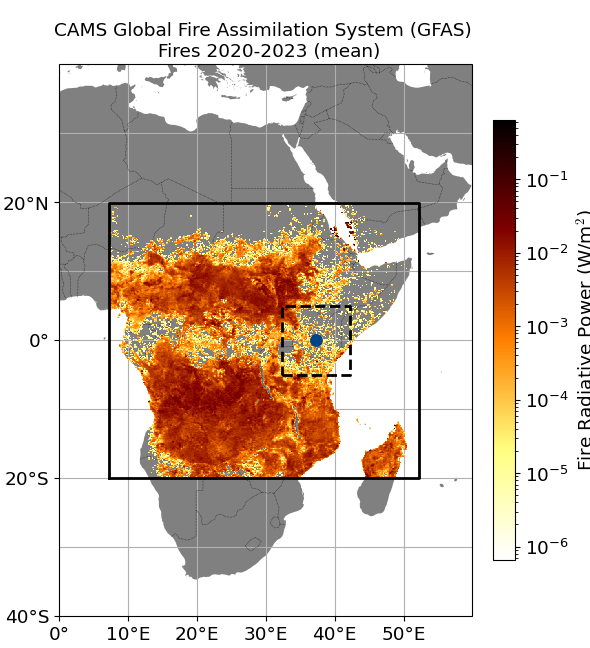

In [133]:
from matplotlib.colors import LogNorm, SymLogNorm
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter

## Show a map with all fire activity for a specific period


gfas_sel = cams_gfas["frpfire"].sel(time=slice(t1, t2)).mean(dim="time")
# only more local fires:
# gfas_sel = cams_gfas.sel(latitude=slice(lat_max,lat_min), longitude = slice(lon_min,lon_max))["frpfire"].sel(time=slice(t1, t2)).mean(dim="time")
gfas_sel = gfas_sel.where(
    gfas_sel != 0, other=np.nan
)  # only plot non-zero values, set all others to nan

# area to map
[lon1, lon2, lat1, lat2] = [0, 60, -40, 40]

# start the figure
projection = ccrs.PlateCarree() # ccrs.Orthographic(central_latitude=40)
fig,ax = plt.subplots(1,1,subplot_kw=dict(projection=projection))
ax.set_extent([lon1, lon2, lat1, lat2], crs=projection)

lands = cfeature.NaturalEarthFeature(
    category="physical", name="land", scale="50m"
)  # cfeature.COLORS['land']
ax.add_feature(lands, zorder=0, facecolor="grey")
ax.add_feature(cfeature.BORDERS, linestyle=":", edgecolor="black")
# ax.add_feature(cfeature.LAKES)
# ax.add_feature(cfeature.RIVERS)

# waters = cfeature.NaturalEarthFeature(category='physical', name='rivers_lake_centerlines',scale= '50m')
# ax.add_feature(waters)

pl = gfas_sel.plot(
    cmap="afmhot_r",
    norm=LogNorm(),
    transform=ccrs.PlateCarree(),
    add_colorbar = False, #add it later
    #cbar_kwargs={"label": "Fire Radiative Power (W/m^2)"},
    rasterized=True,
    zorder=3,
    ax=ax,
)
cbar = mpu.colorbar(
    pl, ax, label= "Fire Radiative Power (W/m$^2$)",shrink=0.2, pad=0.05
)  # shrink: make colorbar shorter
# or: do the log manually for the map:
# plt.pcolormesh(gfas_sel["longitude"],gfas_sel["latitude"],-np.log10(gfas_sel),cmap="hot",transform=ccrs.PlateCarree())
# cbar = plt.colorbar(label="-log(Fire Radiative Power [W/m^2])")
# cbar.set_ticks(np.arange(np.floor(np.min(ds_toplot)), np.ceil(np.max(ds_toplot)) + 1))

# adapt the colorbar
#cbar = mpu.colorbar(pl, ax,orientation='vertical') #requires add_colorbar=False before, but not working yet?
#cbar.set_label("Fire Radiative Power (W/m^2)")

mknlat, mknlon, mknalt = get_station_coords("MKN")
ax.plot(
    mknlon, mknlat, marker="o", color=my_cols.blue, transform=ccrs.PlateCarree(), zorder=5,markersize=8,
)  # mt. kenya station

# define the plotting of a rectangle
def plot_rect(ax, lat_min, lat_max, lon_min, lon_max, color="k",ls='-',lw=2):
    pl = ax.plot(
        [lon_min, lon_max, lon_max, lon_min, lon_min],
        [lat_min, lat_min, lat_max, lat_max, lat_min],
        transform=ccrs.PlateCarree(),
        color=color,
        linestyle=ls,
        linewidth=lw,
        zorder=4,
    )
    return ax, pl

# Add a rectangle to show the available gfas area
gfas_lat_min, gfas_lat_max = [gfas_sel.latitude.min(), gfas_sel.latitude.max()]
gfas_lon_min, gfas_lon_max = [gfas_sel.longitude.min(), gfas_sel.longitude.max()]
plot_rect(ax, gfas_lat_min, gfas_lat_max, gfas_lon_min, gfas_lon_max,lw=lw_thick)

# Add a rectangle to show the local area
plot_rect(ax, lat_min, lat_max, lon_min, lon_max, ls='--',lw=lw_thick)


# set the ticks
ax.set_xticks(np.arange(lon1, lon2, 10), crs=projection)
ax.set_yticks(np.arange(lat1, lat2, 20), crs=projection)

# format the ticks
ax.xaxis.set_major_formatter(LongitudeFormatter())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.gridlines(zorder=1, linestyle="-")
ax.set_xlabel("")
ax.set_ylabel("")


#plt.draw()
fig.subplots_adjust(
    hspace=0.2, wspace=0.2, left=0.1, right=0.8, bottom=0.05, top=0.9
)  # manually adjust spaces to have no cutoff when saving
mpu.set_map_layout(ax, width=15) #set nicer map layout

ax.set_title("CAMS Global Fire Assimilation System (GFAS) \n Fires 2020-2023 (mean)",fontsize='small')
if save_fig:
    plt.savefig(f"{dir_save}fireactivity_map_local_{dlat*2}x{dlon*2}deg.png", dpi=fig_dpi)
    #plt.savefig(f"{dir_save}fireactivity_map_{dlat*2}x{dlon*2}deg.png", dpi=400)
plt.show()

#### Fire time series

In [14]:
# prepare fitting of CO and fire data
# Define fit paramaters for the curve fitting
# Default values
fit_params_defaults = {'shortterm': 45, #Short term cutoff value in days for smoothing of data
                'longterm': 667, # smoothing in days. Default: 667
                'numpolyterms': 3, # use only 2 for less than 3 years of data, otherwise use 3 (=quadratic fit)
                'sampleinterval': 1,  # Use daily data
                'numharmonics': 4}

fit_properties = {}
for dataset_name in ['CO', 'fire_north','fire_south']:
    fit_properties[dataset_name] = fit_params_defaults.copy()
    

Run filter for fire_north
Run filter for fire_south
Run filter for CO


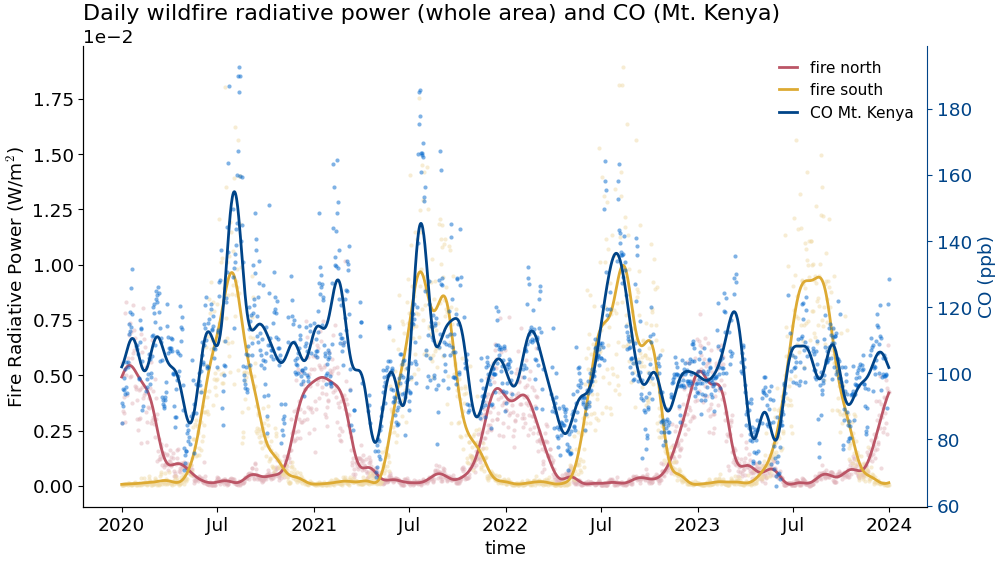

In [127]:
## plot the fireactivity as a time series with CO daily data
# If desired, distinguish between north and south of MKN station

fire_north = (
    cams_gfas.where(cams_gfas.latitude > mknlat)
    .mean(dim="latitude")
    .mean(dim="longitude")
    .sel(time=slice(t1, t2))["frpfire"]
)
fire_south = (
    cams_gfas.where(cams_gfas.latitude < mknlat)
    .mean(dim="latitude")
    .mean(dim="longitude")
    .sel(time=slice(t1, t2))["frpfire"]
)
fire_color = my_cols.red
fire_color2 = my_cols.yellow

# use daily mean CO data
# decide whether to use co data with or without outliers (the fire event)
data_co = (
    ds_all_rem_out.sel(dataset=obs_var)["value"]
    .sel(time=slice(t1, t2))
    .resample(time="1D")
    .mean()
)
meas_color = my_cols.blue

fig, ax = plt.subplots(1, 1, figsize=(figW5, figH5), layout="constrained")

# this would be local activity only
# gfas_mean["frpfire"].plot(label="Total mean fire activity", color="C1")
# gfas_mean_local["frpfire"].plot(label=f"Local fire activity (+/-{dlat}°lat/{dlon}°lon)", color="C3", ls=":")

##----------------- Plot fire data -----------------##
# to distinguish between north and south:
fire_north.plot(
    color=adjust_lightness(fire_color, amount=1.5),
    label="",
    marker="o",
    ls="",
    alpha=marker_transp,
    markeredgewidth=0,
)
fire_south.plot(
    color=adjust_lightness(fire_color2, amount=1.5),
    label="",
    marker="o",
    ls="",
    alpha=marker_transp,
    markeredgewidth=0,
)
## Plot curve fit
for ds, ds_str in zip([fire_north, fire_south], ["fire_north", "fire_south"]):
    filt, df_interp, ds_interp = run_curve_fit.run_ccgfilter(
        ds=ds, dataset_str=ds_str, t1=t1, t2=t2, **fit_properties[ds_str]
    )
    # select in the plot() functin fire_color2 if ds_str == "fire_south" else fire_color:
    if ds_str == "fire_south":
        col = fire_color2
    elif ds_str == "fire_north":
        col = fire_color
    ds_interp["smoothed_vals"].plot(ax=ax, label=ds_str.replace('_',' '), color=col, lw=lw_thick)
plt.title("")
# Axes properties
ax.set_ylabel("Fire Radiative Power (W/m$^2$)")
ax.legend(loc="upper right")
ax.set_title("Daily wildfire radiative power (whole area)", loc="left")

# write the ylabels in scientific notation
# ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
plt.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

##----------------- Plot CO data -----------------##
## plot measurement data
ax2 = ax.twinx()
data_co.plot(
    ax=ax2, label="", marker="", ls="", alpha=marker_transp
)  # plot nothing, just to get the right axis
# ax2.set_ylim([50,300])
ax2.set_ylabel(obs_var)
# set axes to the measurement color
ax2.yaxis.label.set_color(meas_color)
ax2.spines["right"].set_color(meas_color)
ax2.tick_params(axis="y", colors=meas_color)
ax2.spines["right"].set_visible(True)
ax2.set_title("")
ax2.set_ylabel("CO (ppb)")

# save the figure first without measurement data
plt.savefig(f"{dir_save}timeseries_firec_NS_{dlat*2}x{dlon*2}deg.png", dpi=400)

# now plot data
data_co.plot(
    ax=ax2,
    label="",
    color=adjust_lightness(meas_color, amount=1.5),
    marker="o",
    ls="",
    alpha=marker_transp,
    markeredgewidth=0,
)

# add curve fit
filt, df_interp, ds_interp = run_curve_fit.run_ccgfilter(
    ds=data_co, dataset_str="CO", t1=t1, t2=t2, **fit_properties["CO"]
)
ds_interp["smoothed_vals"].plot(
    ax=ax2, label="CO Mt. Kenya", color=meas_color, lw=lw_thick
)  ## adapt hue of initial color (lighter)
ax2.set_ylabel("CO (ppb)")
ax2.set_title("")
ax.set_title(
    "Daily wildfire radiative power (whole area) and CO (Mt. Kenya)", loc="left"
)

# make a single legend for ax and ax2
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc="upper right")

plt.savefig(f"{dir_save}timeseries_fire_CO_NS.png", dpi=400)
plt.show()

#### Check Fire seasonality

Run filter for fire
Run filter for CO
Run filter for fire_local


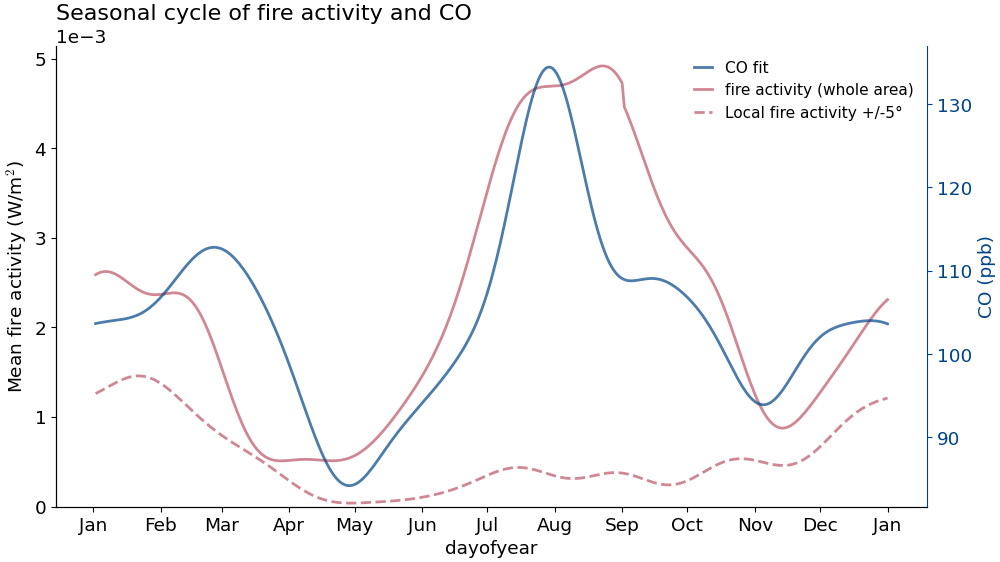

In [130]:
## plot  SEASONAL CYCLE fires (cams) versus CO observations
plot_meas = False # define if to plot only curve fit or also daily measurements
plot_curve = True # plot curve fit (noaa method)

if freq == "month":
    tit = "Seasonal"
elif freq == "hour":
    tit = "Diurnal"
if freq == "dayofyear":
    tit = "Seasonal"

alpha = 0.7
ms = 8

meas_color = my_cols.blue  # CO measurement color
fire_color = my_cols.red  

# resample measurements to 1 day
# meas_1D = (
#     ds_all.sel(dataset=species_sel, time=slice(t1, t2))["value"]
#     .resample(time="D")
#     .mean()
# )
# CO data without outliers
meas_no_out1D = (
    ds_all_rem_out.sel(dataset='CO', time=slice(t1, t2))["value"]
    .resample(time="D")
    .mean()
)

freq = "dayofyear"
fig, ax = plt.subplots(1, 1, sharex=True, figsize=(figW5, figH5), layout="constrained")

# function to plot each subplot
def plot_data(ds, ax, label, c, ls="-",lw=1):
    l = (
        ds.groupby(f"time.{freq}")
        .mean()
        .plot(
            ax=ax,
            ls=ls,
            c=c,
            marker="",
            markeredgewidth=0,
            alpha=alpha,
            markersize=ms,
            label=f"{label}",
            lw=lw
        )
    )
    return l

# plot gfas
gfas_sel = gfas_mean.sel(time=slice(t1, t2))["frpfire"]
if plot_meas:
    l1 = plot_data(
        gfas_sel,
        ax,
        "fire activity (whole area)",
        fire_color,  # fire activity in whole area (from latitude and longitude 0    60, -40    40)
    )
## plot gfas curve fit
if plot_curve:
    filt, df_interp, ds_interp = run_curve_fit.run_ccgfilter(
        ds=gfas_sel, dataset_str='fire', t1=t1, t2=t2, **fit_params_defaults
    )
    l1 = plot_data(ds_interp["smoothed_vals"],ax,label="fire activity (whole area)", c=fire_color,lw=lw_thick)

# axes properties
ax.set_xlabel("Months")
ax.set_title("")
ax.set_ylabel("Mean fire activity (W/m$^2$)")
# write the ylabels in scientific notation:
ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
ax.set_title(f"{tit} cycle of fire activity and CO", loc="left")
ax.set_ylim(bottom=0)# start ylim at zero

# x-axes format
if freq== 'month':
    months = range(1, 13, 3)
    ax.set_xticks(
        months,
        [dt.datetime.strptime(str(month), "%m").strftime("%b") for month in months],
    )
elif freq == 'dayofyear':
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

## -----------Plot CO --------#
# plot obs
ax2 = ax.twinx()
#l2 = plot_data(meas_1D, ax2, "CO MKN", meas_color)
if plot_meas:
    l2 = plot_data(meas_no_out1D, ax2, "CO Mt. Kenya", meas_color, ls="--")

# plot CO curve fit
if plot_curve:
    filt, df_interp, ds_interp = run_curve_fit.run_ccgfilter(
        ds=meas_no_out1D, dataset_str='CO', t1=t1, t2=t2, **fit_params_defaults
    )
    l2 = plot_data(ds_interp["smoothed_vals"],ax2,label='CO fit', c=meas_color,lw=lw_thick)

ax2.spines["right"].set_visible(True)
ax2.set_ylabel("CO (ppb)")
# set axes to the measurement color
ax2.yaxis.label.set_color(meas_color)
ax2.spines["right"].set_color(meas_color)
ax2.tick_params(axis="y", colors=meas_color)
ax2.set_title(" ")
ax2.ticklabel_format(style="plain", axis="y") #no scientific format for CO

# common legend
lns = l2 + l1
# lns = l3 + l2 +l4 #no global fire, only local
labs = [l.get_label() for l in lns]
ax.legend(lns, labs)

# plot first without local fire
if save_fig:
    plt.savefig(f"{dir_save}{tit}_firec_co_{dlat*2}x{dlon*2}deg.png", dpi=500)

## ----------------Plot local fire activity -----------##
# plot local fire activity
if plot_meas:
    l3 = plot_data(
        gfas_sel_local,
        ax,
        f"Local fire activity +/-{dlat}°",
        fire_color,
        ls="--",
    )
## plot gfas curve fit
if plot_curve:
    gfas_sel_local = gfas_mean_local.sel(time=slice(t1, t2))["frpfire"]
    filt, df_interp, ds_interp = run_curve_fit.run_ccgfilter(
        ds=gfas_sel_local, dataset_str='fire_local', t1=t1, t2=t2, **fit_params_defaults
    )
    l3 = plot_data(ds_interp["smoothed_vals"],ax,ls='--',label=f"Local fire activity +/-{dlat}°", c=fire_color,lw=lw_thick)
ax.set_title("")
ax.set_ylabel("Mean fire activity (W/m$^2$)")
# write the ylabels in scientific notation:
#plt.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

# common legend
lns = l2 + l1 + l3
# lns = l3 + l2 +l4 #no global fire, only local
labs = [l.get_label() for l in lns]
ax.legend(lns, labs)

if save_fig:
    plt.savefig(f"{dir_save}{tit}_firec_co_local_{dlat*2}x{dlon*2}deg.png", dpi=500,transparent=False)
plt.show()

### Fire event

In [55]:
from cartopy.feature import ShapelyFeature
from cartopy.io.shapereader import Reader,natural_earth

# Function to plot towns with names on a map
def plot_towns(
    ax, lats, lons, resolution="10m", transform=ccrs.PlateCarree(), zorder=3
):
    """
    This function will download the 'populated_places' shapefile from
    NaturalEarth, trim the shapefile based on the limits of the provided
    lat & long coords, and then plot the locations and names of the towns
    on a given GeoAxes.

    ax = a pyplot axes object
    lats = latitudes
    lons = longitudes
    resolution= str. either high res:'10m' or low res: '50m'
    transform = a cartopy crs object

    From https://gist.github.com/cbur24/9122c763301f6de1d6e1fc39763c2444
    """
    # get town locations
    shp_fn = natural_earth(
        resolution=resolution, category="cultural", name="populated_places"
    )
    shp = Reader(shp_fn)
    xy = [pt.coords[0] for pt in shp.geometries()]
    x, y = list(zip(*xy))

    # get town names
    towns = shp.records()
    names_en = []
    for town in towns:
        names = town.attributes["NAME"]
        names_en.append(names)

    # create data frame and index by the region of the plot
    all_towns = pd.DataFrame({"names_en": names_en, "x": x, "y": y})
    region_towns = all_towns[
        (all_towns.y < np.max(lats))
        & (all_towns.y > np.min(lats))
        & (all_towns.x > np.min(lons))
        & (all_towns.x < np.max(lons))
    ]

    # plot the locations and labels of the towns in the region
    ax.scatter(
        region_towns.x.values,
        region_towns.y.values,
        c="dimgrey",
        marker=".",
        transform=transform,
        zorder=zorder,
    )
    transform_mpl = ccrs.PlateCarree()._as_mpl_transform(
        ax
    )  # this is a work-around to transform xy coords in ax.annotate
    for i, txt in enumerate(region_towns.names_en):
        ax.annotate(
            txt,
            (region_towns.x.values[i], region_towns.y.values[i]),
            xycoords=transform_mpl,
            textcoords="offset points",
            xytext=(3, 3), #text offset in points
            color='dimgrey',
            fontsize='x-small'
        )

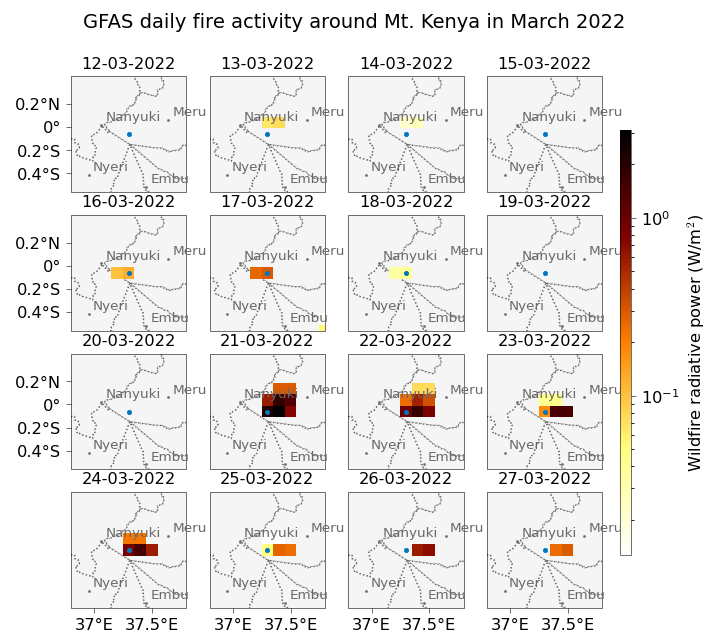

In [61]:
## Plot fire activity in a given area for selected dates

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import mplotutils as mpu

d1 = "2022-03-12"
d2 = "2022-03-27"
# d1 = "2021-03-20"
# d2 = "2021-03-28"
len_days = len(pd.date_range(start=d1, end=d2))
nrows = 4  # nbr of rows
#ncols = 5
var = "frpfire"
# area to map
dx = 0.5  # in degrees
dy = 0.5
[lon1, lon2, lat1, lat2] = [mknlon - dx, mknlon + dx, mknlat - dy, mknlat + dy]
ds_sel = cams_gfas.sel(
    time=slice(d1, d2), latitude=slice(lat2, lat1), longitude=slice(lon1, lon2)
)
ds_sel = ds_sel.where(
    ds_sel != 0, other=np.nan
)  # only plot non-zero values, set all others to nan

projection = ccrs.PlateCarree()  # ccrs.Orthographic(central_latitude=40)

fig, axs = plt.subplots(
    nrows,
    int(len_days / nrows),
    subplot_kw=dict(projection=projection),
    sharex=True,
    sharey=True,
)  # , figsize=(8, 8))
axs = axs.flatten()
vmin = ds_sel[var].min()
vmax = ds_sel[var].max()


for ii, (d, ax) in enumerate(zip(pd.date_range(start=d1, end=d2), axs)):
    ax.set_extent([lon1, lon2, lat1, lat2], crs=projection)

    # Add Kenya county borders
    filename = r".\kenyan-counties\County.shp"
    shape_feature = ShapelyFeature(
        Reader(filename).geometries(),
        ccrs.PlateCarree(),
        linewidth=1,
        facecolor="whitesmoke",
        edgecolor="dimgrey",
        linestyle=":",
    )
    ax.add_feature(shape_feature)

    im = ds_sel.sel(time=d)[var].plot(
        cmap="afmhot_r",
        norm=LogNorm(),
        transform=ccrs.PlateCarree(),
        rasterized=True,
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False,
        zorder=2,
    )

    # plot town locations
    lons = np.arange(lon1, lon2, 0.1)
    lats = np.arange(lat1, lat2, 0.1)
    plot_towns(ax, lats, lons)

    ax.plot(mknlon, mknlat, marker="o", color="C0",label='Mt. Kenya')  # mt. kenya station
    # write Mt. Kenya label
    # ax.annotate(
    #     "Mt. Kenya",
    #     (mknlon, mknlat),
    #     xycoords=ccrs.PlateCarree()._as_mpl_transform(ax),
    #     textcoords="offset points",
    #     xytext=(3, -4),  # text offset in points
    #     color="C0",
    #     verticalalignment="top",
    #     horizontalalignment="left",
    #     # backgroundcolor = 'white',
    #     # alpha=0.5
    # )

    # no axes labels
    ax.set_ylabel("")
    ax.set_xlabel("")

    ### Ticks and labels
    if ii in [0, len_days / nrows, (len_days / nrows) * 2]:  # only first column
        # set the yticks
        ax.set_yticks(np.arange(round(lat1, 1), round(lat2, 1), 0.2), crs=projection)
        ax.yaxis.set_major_formatter(LatitudeFormatter())
    if ii > (len_days / nrows * (nrows-1))-1:  # only lowest row
        ax.set_xticks(np.arange(round(lon1), round(lon2), 0.5), crs=projection)
        # format the ticks
        ax.xaxis.set_major_formatter(LongitudeFormatter())
        # ax.gridlines(zorder=1, linestyle="-")

    # no axes labels
    ax.set_ylabel("")
    ax.set_xlabel("")
    # axis title:
    month_str = dt.datetime.strptime(str(d.month), "%m").strftime("%B")
    ax.set_title(f"{d.day}-{d.month:02d}-{d.year}", fontsize="small")

cbar = mpu.colorbar(
    im,
    ax=[axs[int(len_days / nrows)-1], axs[-1]],
    pad=0.15,
    size=0.1,
    orientation="vertical",
    label="Wildfire radiative power (W/m$^2$)",
    shrink=.2
)

# ax.set_xlabel("Longitude")
# ax.set_ylabel("Latitude")
fig.subplots_adjust(
    hspace=0.2, wspace=0.2, left=0.1, right=0.85, bottom=0.05, top=0.88
)  # manually adjust spaces to have no cutoff when saving
mpu.set_map_layout(axs, width=18)

plt.suptitle(f"GFAS daily fire activity around Mt. Kenya in {month_str} {d.year}")

if save_fig:
    plt.savefig(f"{dir_save}fireevent_gfas_MKN_{d.month:02d}{d.year}.png", dpi=fig_dpi)
plt.show()